# Explore here

In [114]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv")
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [115]:
total_data = total_data.drop_duplicates().reset_index(drop = True)
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [116]:
import json

# Diccionario con la factorización y preprocesamiento del dataset
preprocessing_factors_fixed = {
    "source": "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv",
    "steps": [
        "Cargar datos desde CSV",
        "Eliminar duplicados",
        "División en variables (X) y target (y)",
        {
            "Selección de características con SelectKBest (k=7)": [
                "Pregnancies", "Glucose", "BloodPressure", "Insulin",
                "BMI", "DiabetesPedigreeFunction", "Age"
            ]
        },
        "División en entrenamiento y prueba (80% / 20%)",
        "Guardado en clean_train.csv y clean_test.csv"
    ],
    "train_test_split": {
        "train_size": 0.8,
        "test_size": 0.2,
        "random_state": 42
    },
    "model": {
        "type": "DecisionTreeClassifier",
        "original_accuracy": 0.7597,
        "optimized_accuracy": 0.7727,
        "best_params": {
            "criterion": "entropy",
            "max_depth": 5,
            "min_samples_leaf": 4,
            "min_samples_split": 2
        }
    },
    "output_files": [
        "data/processed/clean_train.csv",
        "data/processed/clean_test.csv",
        "models/tree_classifier_crit-entro_maxdepth-5_minleaf-4_minsplit2_42.sav"
    ]
}

# Guardar como archivo JSON en tu directorio actual
with open("preprocessing_factors_fixed.json", "w") as f:
    json.dump(preprocessing_factors_fixed, f, indent=4)

print("Archivo guardado como preprocessing_factors_fixed.json")


Archivo guardado como preprocessing_factors_fixed.json


In [117]:
import pandas as pd
import json

# Usamos el dataset ya limpio (sin duplicados)
clean_data = total_data.copy()

# Crear versiones con y sin outliers
clean_data_con_outliers = clean_data.copy()
clean_data_sin_outliers = clean_data.copy()

# Función para reemplazar outliers usando IQR
def replace_outliers_from_column(column, df):
    column_stats = df[column].describe()
    column_iqr = column_stats["75%"] - column_stats["25%"]
    upper_limit = column_stats["75%"] + 1.5 * column_iqr
    lower_limit = column_stats["25%"] - 1.5 * column_iqr
    if lower_limit < 0: lower_limit = 0  # No valores negativos para algunas columnas
    # Reemplazar valores superiores
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    # Reemplazar valores inferiores
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy(), [float(lower_limit), float(upper_limit)]

# Diccionario donde guardaremos los límites de outliers
outliers_dict = {}

# Lista de columnas numéricas a revisar (todas excepto 'Outcome')
columns_to_check = [col for col in clean_data.columns if col != "Outcome"]

# Aplicar función a cada columna
for column in columns_to_check:
    clean_data_sin_outliers, limits = replace_outliers_from_column(column, clean_data_sin_outliers)
    outliers_dict[column] = limits

# Guardar el diccionario en un archivo JSON
with open("outliers_dict.json", "w") as f:
    json.dump(outliers_dict, f, indent=4)

print("Outliers procesados y guardados en 'outliers_dict.json'")


Outliers procesados y guardados en 'outliers_dict.json'


In [118]:
outliers_dict = {
    "Pregnancies": [0.0, 13.5],
    "Glucose": [44.25, 198.75],
    "BloodPressure": [24.0, 104.0],
    "Insulin": [0.0, 400.5],
    "BMI": [18.5, 50.0],
    "DiabetesPedigreeFunction": [0.08, 1.8],
    "Age": [21.0, 65.0]
}


In [119]:
import pandas as pd
import json
import os

# Simular carga de datos (puedes reemplazar esto con tu archivo real)
data = {
    "Pregnancies": [6, 1, 8, 1, 0],
    "Glucose": [148, 85, 183, 89, 137],
    "BloodPressure": [72, 66, 64, 66, 40],
    "SkinThickness": [35, 29, 0, 23, 35],
    "Insulin": [0, 0, 0, 94, 168],
    "BMI": [33.6, 26.6, 23.3, 28.1, 43.1],
    "DiabetesPedigreeFunction": [0.627, 0.351, 0.672, 0.167, 2.288],
    "Age": [50, 31, 32, 21, 33],
    "Outcome": [1, 0, 1, 0, 1]
}

# Cargar datos al DataFrame
clean_data = pd.DataFrame(data)

# Crear copias con y sin outliers
clean_data_con_outliers = clean_data.copy()
clean_data_sin_outliers = clean_data.copy()

# Función para reemplazar outliers usando IQR
def replace_outliers_from_column(column, df):
    column_stats = df[column].describe()
    column_iqr = column_stats["75%"] - column_stats["25%"]
    upper_limit = column_stats["75%"] + 1.5 * column_iqr
    lower_limit = column_stats["25%"] - 1.5 * column_iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy(), [float(lower_limit), float(upper_limit)]

# Diccionario para registrar los límites de outliers
outliers_dict = {}
columns_to_check = [col for col in clean_data.columns if col != "Outcome"]

# Aplicar reemplazo de outliers a cada columna
for column in columns_to_check:
    clean_data_sin_outliers, limits = replace_outliers_from_column(column, clean_data_sin_outliers)
    outliers_dict[column] = limits

# Crear carpeta local si no existe
os.makedirs("data", exist_ok=True)

# Guardar archivos CSV
clean_data_con_outliers.to_csv("data/diabetes_con_outliers.csv", index=False)
clean_data_sin_outliers.to_csv("data/diabetes_sin_outliers.csv", index=False)

# Guardar diccionario de outliers en JSON
with open("data/outliers_dict.json", "w") as f:
    json.dump(outliers_dict, f, indent=4)

print("✅ Archivos guardados exitosamente en la carpeta 'data'")


✅ Archivos guardados exitosamente en la carpeta 'data'


In [120]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Variables numéricas del dataset de diabetes (sin 'Outcome')
num_variables = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

# Cargar los datos procesados (con y sin outliers)
clean_data_con_outliers = pd.read_csv("data/diabetes_con_outliers.csv")
clean_data_sin_outliers = pd.read_csv("data/diabetes_sin_outliers.csv")

# Separar features (X) y target (y)
X_con_outliers = clean_data_con_outliers[num_variables]
X_sin_outliers = clean_data_sin_outliers[num_variables]
y = clean_data_con_outliers["Outcome"]

# Dividir en train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42
)
X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42
)

# Crear carpeta si no existe
processed_path = "data/processed"
os.makedirs(processed_path, exist_ok=True)

# Guardar datasets como archivos Excel
X_train_con_outliers.to_excel(/Users/mariannacastro/Desktop/4Geeks/proyectos/decision-tree-Mari/data/processed}/X_train_con_outliers.xlsx", index=False)
X_test_con_outliers.to_excel(/Users/mariannacastro/Desktop/4Geeks/proyectos/decision-tree-Mari/data/processed}/X_test_con_outliers.xlsx", index=False)
X_train_sin_outliers.to_excel(/Users/mariannacastro/Desktop/4Geeks/proyectos/decision-tree-Mari/data/processed}/X_train_sin_outliers.xlsx", index=False)
X_test_sin_outliers.to_excel(/Users/mariannacastro/Desktop/4Geeks/proyectos/decision-tree-Mari/data/processed}/X_test_sin_outliers.xlsx", index=False)
y_train.to_excel(/Users/mariannacastro/Desktop/4Geeks/proyectos/decision-tree-Mari/data/processed}/y_train.xlsx", index=False)
y_test.to_excel(/Users/mariannacastro/Desktop/4Geeks/proyectos/decision-tree-Mari/data/processed}/y_test.xlsx", index=False)

print("✅ Archivos .xlsx guardados en la carpeta 'data/processed'")


SyntaxError: invalid decimal literal (1532136337.py, line 33)

In [91]:
# No normalization of variables is needed for training this model

# Feature selection

from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split

X = total_data.drop("Outcome", axis = 1)
y = total_data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

selection_model = SelectKBest(k = 7)
selection_model.fit(X_train, y_train)

selected_columns = X_train.columns[selection_model.get_support()]
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = selected_columns)

X_train_sel.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2.0,84.0,0.0,0.0,0.0,0.304,21.0
1,9.0,112.0,82.0,0.0,28.2,1.282,50.0
2,1.0,139.0,46.0,83.0,28.7,0.654,22.0
3,0.0,161.0,50.0,0.0,21.9,0.254,65.0
4,6.0,134.0,80.0,370.0,46.2,0.238,46.0


In [92]:
X_test_sel.head()


,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,98.0,58.0,190.0,34.0,0.430,43.0
1,2.0,112.0,75.0,0.0,35.7,0.148,21.0
2,2.0,108.0,64.0,0.0,30.8,0.158,21.0
3,8.0,107.0,80.0,0.0,24.6,0.856,34.0
4,7.0,136.0,90.0,0.0,29.9,0.210,50.0


In [93]:
X_train_sel["Outcome"] = y_train.values
X_test_sel["Outcome"] = y_test.values
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)

Decision Tree model

In [94]:
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2.0,84.0,0.0,0.0,0.0,0.304,21.0,0
1,9.0,112.0,82.0,0.0,28.2,1.282,50.0,1
2,1.0,139.0,46.0,83.0,28.7,0.654,22.0,0
3,0.0,161.0,50.0,0.0,21.9,0.254,65.0,0
4,6.0,134.0,80.0,370.0,46.2,0.238,46.0,1


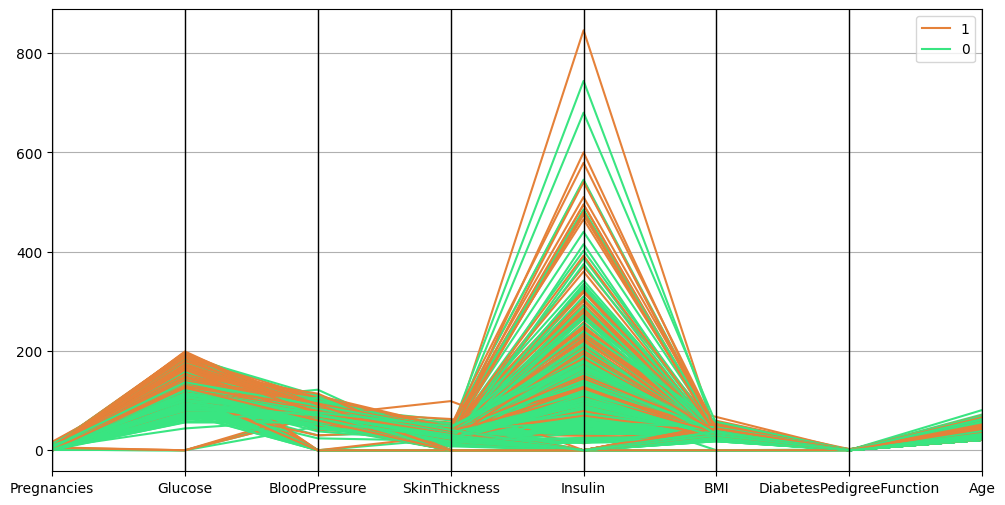

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

pd.plotting.parallel_coordinates(total_data, "Outcome", color = ("#E58139", "#39E581", "#8139E5"))

plt.show()

In [96]:
X_train = train_data.drop(["Outcome"], axis = 1)
y_train = train_data["Outcome"]
X_test = test_data.drop(["Outcome"], axis = 1)
y_test = test_data["Outcome"]

In [97]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

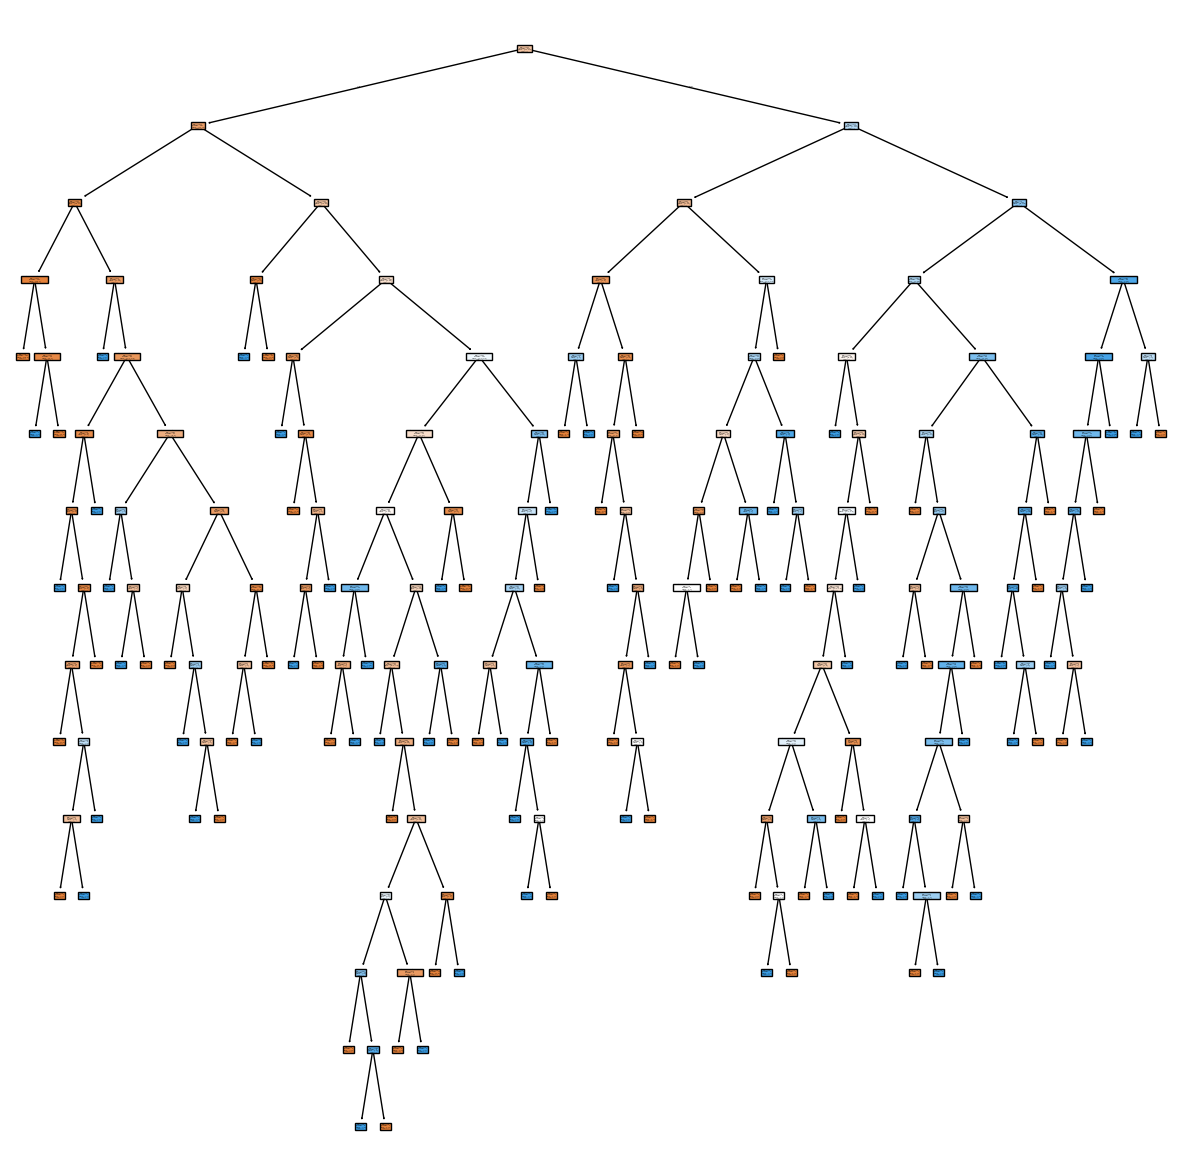

In [ ]:
from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)

plt.show()

In [99]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [100]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7597402597402597

Model optimization

In [101]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

hyperparams = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 10)
grid

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

grid.fit(X_train, y_train)

print(f"Best hyperparameters: {grid.best_params_}")

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [103]:
model = DecisionTreeClassifier(criterion = "entropy", max_depth = 5, min_samples_leaf = 4, min_samples_split = 2, random_state = 42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4,
                       random_state=42)

In [104]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [105]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7727272727272727

In [106]:
from pickle import dump

dump(model, open("../models/tree_classifier_crit-entro_maxdepth-5_minleaf-4_minsplit2_42.sav", "wb"))